In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from services.files import get_files
from services.distortion import hard_clip
from services.distortion import soft_clip
from services.distortion import bitcrush
from services.distortion import wavefold
from services.fuzz import fuzz 
import os
import librosa
import matplotlib.pyplot as plt

In [ ]:

torch.set_default_device('cpu')


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
files = get_files()
print(len(files))
print(files[:5])

2913
['TinySOL\\Brass\\Bass_Tuba\\ordinario\\BTb-ord-A#1-ff-N-T30d.wav', 'TinySOL\\Brass\\Bass_Tuba\\ordinario\\BTb-ord-A#1-mf-N-N.wav', 'TinySOL\\Brass\\Bass_Tuba\\ordinario\\BTb-ord-A#1-pp-N-N.wav', 'TinySOL\\Brass\\Bass_Tuba\\ordinario\\BTb-ord-A#2-ff-N-T19u.wav', 'TinySOL\\Brass\\Bass_Tuba\\ordinario\\BTb-ord-A#2-mf-N-T29u.wav']


In [ ]:
AudioData = []
TargetSeconds = 3
TargetSamples = TargetSeconds * 44100 

for file in files:
    audio, sr = librosa.load(file, sr=44100)
    audio = audio/ np.max(np.abs(audio)) #normalization
    audio_fixed = librosa.util.fix_length(audio, size=TargetSamples)
    AudioData.append(audio_fixed)


AudioData = np.array(AudioData)
print(AudioData.shape)

c:\Dev\Projects\Distortion_ML\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2913, 132300)


[[ 0.0000000e+00  0.0000000e+00  1.4452955e-04 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ... -2.1752988e-01
  -2.2788845e-01 -2.3585658e-01]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ... -1.0321101e-01
  -1.0550459e-01 -1.0550459e-01]
 ...
 [ 0.0000000e+00 -1.6079756e-04 -1.6079756e-04 ... -7.2809136e-01
  -7.1410197e-01 -5.9093100e-01]
 [ 0.0000000e+00  0.0000000e+00  2.3849272e-04 ... -3.5606965e-01
  -2.5017887e-01 -7.0593849e-02]
 [ 1.1376564e-03  0.0000000e+00  0.0000000e+00 ... -5.9726965e-01
  -5.6882823e-01 -5.3924912e-01]] (132300,) (132300,)
2


In [ ]:
#Distortion

HardClipDistortedAudioData = AudioData.copy()
for i in range(len(AudioData)):
    HardClipDistortedAudioData[i] = hard_clip(AudioData[i], threshold=0.5)

SoftClipDistortedAudioData = AudioData.copy()
for i in range(len(AudioData)):
    SoftClipDistortedAudioData[i] = soft_clip(AudioData[i], gain=3)

BitCrushedAudioData = AudioData.copy()
for i in range(len(AudioData)):
    BitCrushedAudioData[i] = bitcrush(AudioData[i])

WaveFoldedAudioData = AudioData.copy()
for i in range(len(AudioData)):
    WaveFoldedAudioData[i] = wavefold(AudioData[i])


In [ ]:
#Fuzz

TremoloAudioData = AudioData.copy()
for i in range(len(AudioData)):
    TremoloAudioData[i] = fuzz(AudioData[i])

In [ ]:
X_tensor = torch.tensor(AudioData, dtype=torch.float32)


#Distortion
HardClipTensor = torch.tensor(HardClipDistortedAudioData, dtype=torch.float32)
SoftClipTensor = torch.tensor(SoftClipDistortedAudioData, dtype=torch.float32)
BitCrushedATensor = torch.tensor(BitCrushedAudioData, dtype=torch.float32)
WaveFoldedTensor = torch.tensor(WaveFoldedAudioData, dtype=torch.float32)


#Tremolo 

TremoloTensor = torch.tensor(TremoloAudioData, dtype = torch.float32)


print(X_tensor.shape)


torch.Size([2913, 132300])


In [ ]:
win_length = n_fft = 1024
window= torch.hann_window(win_length)

In [ ]:
class AudioCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 1, kernel_size=5, padding=2),
            nn.Tanh()

        )

    def forward(self, x):
        return self.net(x)


model = AudioCNN()

In [ ]:
class HardClipCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=1, padding=0),
            nn.ReLU(),
            
            nn.Conv1d(16, 32, kernel_size=1, padding=0),
            nn.ReLU(),
            
            nn.Conv1d(32, 16, kernel_size=1, padding=0),
            nn.ReLU(),
            
            
            nn.Conv1d(16, 1, kernel_size=1, padding=0)
        )

    def forward(self, x):
        return self.net(x)


model = HardClipCNN()




Input shape: torch.Size([256, 1, 64])
Output shape: torch.Size([256, 1, 64])


In [ ]:
#SOFT CLIP DISTORTION

window_size = 64

stride = 64

MaxSamples = 55000
TestSize = 20000

X_windows_SC = []
SoftClipWindows = []

for clean, distorted in zip(X_tensor,SoftClipTensor ):

    for i in range(0, clean.shape[0] - window_size, stride):

        X_windows_SC.append(clean[i:i+window_size])
        SoftClipWindows.append(distorted[i:i+window_size])

X_windows_SC = torch.stack(X_windows_SC)
SoftClipWindows = torch.stack(SoftClipWindows)

In [ ]:
#Wave folding 


window_size = 64
stride = 64

MaxSamples = 55000
TestSize = 20000

X_windows_HC = []
HardClipWindows = []

for clean, distorted in zip(X_tensor,WaveFoldedTensor ):

    for i in range(0, clean.shape[0] - window_size, stride):

        X_windows_HC.append(clean[i:i+window_size])
        HardClipWindows.append(distorted[i:i+window_size])

X_windows_HC = torch.stack(X_windows_HC)
HardClipWindows = torch.stack(HardClipWindows)

In [ ]:
#Fuzz
window_size = 64
stride = 64
MaxSamples = 55000
TestSize = 20000

X_windows_TM = []
TremoloWindows = [] 

for clean, distorted in zip(X_tensor, TremoloTensor):
    
    num_samples = clean.shape[0]
    
    for i in range(0, num_samples - window_size, stride):
        
        X_windows_TM.append(clean[i:i+window_size])
        TremoloWindows.append(distorted[i:i+window_size])



X_windows_TM = torch.stack(X_windows_TM)
TremoloWindows = torch.stack(TremoloWindows)


X_windows_TM = X_windows_TM.unsqueeze(1)    
TremoloWindows = TremoloWindows.unsqueeze(1) 



print(f"Final Input Shape {X_windows_TM.shape}") 
print(f"Final Target Shape {TremoloWindows.shape}")

Final Input Shape (Audio): torch.Size([6021171, 1, 64])
Final Target Shape (Fuzz): torch.Size([6021171, 1, 64])


In [ ]:
print(X_windows_SC.shape, SoftClipWindows.shape)
print(X_windows_HC.shape, HardClipWindows.shape)

torch.Size([6021171, 64]) torch.Size([6021171, 64])
torch.Size([6021171, 64]) torch.Size([6021171, 64])


In [ ]:
#Soft Clip

X_windows_SC = X_windows_SC.view(-1, 1, 64)
SoftClipWindows = SoftClipWindows.view(-1, 1, 64)

#split
MaxSamples = 55000
TestSize = 20000

X_train_SC = X_windows_SC[:MaxSamples]
Y_train_SC = SoftClipWindows[:MaxSamples]

X_test_SC = X_windows_SC[MaxSamples:MaxSamples + TestSize]
Y_test_SC = SoftClipWindows[MaxSamples:MaxSamples + TestSize]

print(X_train_SC.shape, X_test_SC.shape)

torch.Size([55000, 1, 64]) torch.Size([20000, 1, 64])


In [ ]:
#Hard Clip

X_windows_HC = X_windows_HC.view(-1, 1, 64)
HardClipWindows = HardClipWindows.view(-1, 1, 64)

#split
MaxSamples = 55000
TestSize = 20000

X_train_HC = X_windows_HC[:MaxSamples]
Y_train_HC = HardClipWindows[:MaxSamples]

X_test_HC = X_windows_HC[MaxSamples:MaxSamples + TestSize]
Y_test_HC = HardClipWindows[MaxSamples:MaxSamples + TestSize]

print(X_train_HC.shape, X_test_HC.shape)

torch.Size([55000, 1, 64]) torch.Size([20000, 1, 64])


In [ ]:
# fuzz

X_windows_TM = X_windows_TM.view(-1, 1, 64) 


TremoloWindows = TremoloWindows.view(-1, 1, 64)

MaxSamples = 55000
TestSize = 20000

X_train_TM = X_windows_TM[:MaxSamples]
Y_train_TM = TremoloWindows[:MaxSamples]

X_test_TM = X_windows_TM[MaxSamples:MaxSamples + TestSize]
Y_test_TM = TremoloWindows[MaxSamples:MaxSamples + TestSize]

print(f"X Train Shape: {X_train_TM.shape}") # Expected: [55000, 1, 64]
print(f"Y Train Shape: {Y_train_TM.shape}") # Expected: [55000, 1, 64]
print(f"X Test Shape:  {X_test_TM.shape}")  # Expected: [20000, 1, 64]
print(f"Y Test Shape:  {Y_test_TM.shape}")  # Expected: [20000, 1, 64]

X Train Shape: torch.Size([55000, 1, 64])
Y Train Shape: torch.Size([55000, 1, 64])
X Test Shape:  torch.Size([20000, 1, 64])
Y Test Shape:  torch.Size([20000, 1, 64])


In [ ]:
#Soft CLip

TrainDataset_SC = TensorDataset(X_train_SC, Y_train_SC)

loader_SC = DataLoader(TrainDataset_SC,
                    batch_size=256,
                    shuffle=True,
                    num_workers=0)


TestDataset_SC = TensorDataset(X_test_SC, Y_test_SC)

TestLoader_SC = DataLoader(TestDataset_SC,
                         batch_size=256,
                         shuffle=False,
                         num_workers=0)

In [ ]:
#Hard CLip



TrainDataset_HC = TensorDataset(X_train_HC, Y_train_HC)

loader_HC = DataLoader(TrainDataset_HC,
                    batch_size=256,
                    shuffle=True,
                    num_workers=0)


TestDataset_HC = TensorDataset(X_test_HC, Y_test_HC)

TestLoader_HC = DataLoader(TestDataset_HC,
                         batch_size=256,
                         shuffle=False,
                         num_workers=0)

In [ ]:
#Tremolo



TrainDataset_TM = TensorDataset(X_train_TM, Y_train_TM)

loader_TM = DataLoader(TrainDataset_TM,
                    batch_size=256,
                    shuffle=True,
                    num_workers=0)


TestDataset_TM = TensorDataset(X_test_TM, Y_test_TM)

TestLoader_TM = DataLoader(TestDataset_TM,
                         batch_size=256,
                         shuffle=False,
                         num_workers=0)

In [ ]:
for batch_x, batch_y in loader_SC:
    print(batch_x.shape)
    break

torch.Size([256, 1, 64])


In [ ]:
SoftClipModel = AudioCNN()
criterion_SC = nn.MSELoss()
optimizer_SC = torch.optim._Adam(SoftClipModel.parameters(), lr=0.0005)
SoftClipModel = SoftClipModel.to(device)

print(len(loader_SC.dataset))

55000


In [ ]:

HardClipModel = HardClipCNN().to(device)
criterion_HC = nn.MSELoss()
optimizer_HC = torch.optim.Adam(HardClipModel.parameters(), lr=0.0005)

print(len(loader_HC.dataset))

55000


In [ ]:

TremoloModel = HardClipCNN().to(device)
criterion_TM = nn.MSELoss()
optimizer_TM = torch.optim.Adam(TremoloModel.parameters(), lr=0.0005)

print(len(loader_TM.dataset))

55000


In [ ]:
SoftClipModel = SoftClipModel.to(device)

SoftClipModel.train()
epochs = 50
for epoch in range(epochs):

    total_loss = 0

    for batch_x, batch_y in loader_SC:

        
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = SoftClipModel(batch_x)

        loss = criterion_SC(pred, batch_y)

        optimizer_SC.zero_grad()
        loss.backward()
        optimizer_SC.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader_SC):.6f}")

Epoch 1, Loss: 0.035609
Epoch 2, Loss: 0.000795
Epoch 3, Loss: 0.000201
Epoch 4, Loss: 0.000091
Epoch 5, Loss: 0.000056
Epoch 6, Loss: 0.000040
Epoch 7, Loss: 0.000032
Epoch 8, Loss: 0.000028
Epoch 9, Loss: 0.000023
Epoch 10, Loss: 0.000022
Epoch 11, Loss: 0.000019
Epoch 12, Loss: 0.000018
Epoch 13, Loss: 0.000017
Epoch 14, Loss: 0.000017
Epoch 15, Loss: 0.000016
Epoch 16, Loss: 0.000015
Epoch 17, Loss: 0.000016
Epoch 18, Loss: 0.000020
Epoch 19, Loss: 0.000009
Epoch 20, Loss: 0.000013
Epoch 21, Loss: 0.000016
Epoch 22, Loss: 0.000019
Epoch 23, Loss: 0.000007
Epoch 24, Loss: 0.000011
Epoch 25, Loss: 0.000011
Epoch 26, Loss: 0.000012
Epoch 27, Loss: 0.000011
Epoch 28, Loss: 0.000011
Epoch 29, Loss: 0.000012
Epoch 30, Loss: 0.000010
Epoch 31, Loss: 0.000011
Epoch 32, Loss: 0.000010
Epoch 33, Loss: 0.000010
Epoch 34, Loss: 0.000011
Epoch 35, Loss: 0.000009
Epoch 36, Loss: 0.000011
Epoch 37, Loss: 0.000010
Epoch 38, Loss: 0.000009
Epoch 39, Loss: 0.000010
Epoch 40, Loss: 0.000008
Epoch 41,

In [ ]:
HardClipModel = HardClipModel.to(device)

HardClipModel.train()
epochs = 50
for epoch in range(epochs):

    total_loss = 0

    for batch_x, batch_y in loader_HC:

        
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = HardClipModel(batch_x)

        loss = criterion_HC(pred, batch_y)

        optimizer_HC.zero_grad()
        loss.backward()
        optimizer_HC.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader_HC):.6f}")

Epoch 1, Loss: 0.021635
Epoch 2, Loss: 0.001203
Epoch 3, Loss: 0.000629
Epoch 4, Loss: 0.000402
Epoch 5, Loss: 0.000250
Epoch 6, Loss: 0.000150
Epoch 7, Loss: 0.000084
Epoch 8, Loss: 0.000043
Epoch 9, Loss: 0.000019
Epoch 10, Loss: 0.000007
Epoch 11, Loss: 0.000003
Epoch 12, Loss: 0.000001
Epoch 13, Loss: 0.000000
Epoch 14, Loss: 0.000000
Epoch 15, Loss: 0.000000
Epoch 16, Loss: 0.000000
Epoch 17, Loss: 0.000000
Epoch 18, Loss: 0.000000
Epoch 19, Loss: 0.000000
Epoch 20, Loss: 0.000000
Epoch 21, Loss: 0.000000
Epoch 22, Loss: 0.000000
Epoch 23, Loss: 0.000000
Epoch 24, Loss: 0.000000
Epoch 25, Loss: 0.000000
Epoch 26, Loss: 0.000000
Epoch 27, Loss: 0.000000
Epoch 28, Loss: 0.000000
Epoch 29, Loss: 0.000000
Epoch 30, Loss: 0.000000
Epoch 31, Loss: 0.000000
Epoch 32, Loss: 0.000000
Epoch 33, Loss: 0.000000
Epoch 34, Loss: 0.000000
Epoch 35, Loss: 0.000000
Epoch 36, Loss: 0.000000
Epoch 37, Loss: 0.000000
Epoch 38, Loss: 0.000000
Epoch 39, Loss: 0.000000
Epoch 40, Loss: 0.000000
Epoch 41,

In [ ]:
TremoloModel = TremoloModel.to(device)

TremoloModel.train()
epochs = 50
for epoch in range(epochs):

    total_loss = 0

    for batch_x, batch_y in loader_TM:

        
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = TremoloModel(batch_x)

        loss = criterion_TM(pred, batch_y)

        optimizer_TM.zero_grad()
        loss.backward()
        optimizer_TM.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader_TM):.6f}")

Epoch 1, Loss: 0.068876
Epoch 2, Loss: 0.010490
Epoch 3, Loss: 0.003202
Epoch 4, Loss: 0.000581
Epoch 5, Loss: 0.000093
Epoch 6, Loss: 0.000030
Epoch 7, Loss: 0.000013
Epoch 8, Loss: 0.000007
Epoch 9, Loss: 0.000004
Epoch 10, Loss: 0.000003
Epoch 11, Loss: 0.000002
Epoch 12, Loss: 0.000002
Epoch 13, Loss: 0.000001
Epoch 14, Loss: 0.000001
Epoch 15, Loss: 0.000001
Epoch 16, Loss: 0.000001
Epoch 17, Loss: 0.000001
Epoch 18, Loss: 0.000001
Epoch 19, Loss: 0.000001
Epoch 20, Loss: 0.000001
Epoch 21, Loss: 0.000001
Epoch 22, Loss: 0.000001
Epoch 23, Loss: 0.000001
Epoch 24, Loss: 0.000001
Epoch 25, Loss: 0.000001
Epoch 26, Loss: 0.000001
Epoch 27, Loss: 0.000001
Epoch 28, Loss: 0.000001
Epoch 29, Loss: 0.000001
Epoch 30, Loss: 0.000001
Epoch 31, Loss: 0.000001
Epoch 32, Loss: 0.000001
Epoch 33, Loss: 0.000001
Epoch 34, Loss: 0.000001
Epoch 35, Loss: 0.000002
Epoch 36, Loss: 0.000001
Epoch 37, Loss: 0.000000
Epoch 38, Loss: 0.000001
Epoch 39, Loss: 0.000001
Epoch 40, Loss: 0.000001
Epoch 41,

In [ ]:
#debug
print("Train size:", len(loader_SC.dataset))
print("Test size :", len(TestLoader_SC.dataset))
    

Train size: 55000
Test size : 20000


In [ ]:
#eval
with torch.no_grad():

    for batch_x, batch_y in loader_SC:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = SoftClipModel(batch_x)

        loss = criterion_SC(pred, batch_y)

        print("Eval Loss:", loss.item())
        break


SoftClipModel.eval()

test_loss = 0

with torch.no_grad():

    for batch_x, batch_y in TestLoader_SC:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = SoftClipModel(batch_x)

        loss = criterion_SC(pred, batch_y)

        test_loss += loss.item()

print("Test Loss:", test_loss / len(TestLoader_SC))

Eval Loss: 4.9484569899505004e-06
Test Loss: 3.2397245641858935e-06


In [ ]:
#eval
with torch.no_grad():

    for batch_x, batch_y in loader_HC:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = HardClipModel(batch_x)

        loss = criterion_HC(pred, batch_y)

        print("Eval Loss:", loss.item())
        break


HardClipModel.eval()

test_loss = 0

with torch.no_grad():

    for batch_x, batch_y in TestLoader_HC:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = HardClipModel(batch_x)

        loss = criterion_HC(pred, batch_y)

        test_loss += loss.item()

print("Test Loss:", test_loss / len(TestLoader_HC))

Eval Loss: 3.357922651048284e-08
Test Loss: 2.42882454588111e-08


In [ ]:
#eval
with torch.no_grad():

    for batch_x, batch_y in loader_TM:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = TremoloModel(batch_x)

        loss = criterion_TM(pred, batch_y)

        print("Eval Loss:", loss.item())
        break


TremoloModel.eval()

test_loss = 0

with torch.no_grad():

    for batch_x, batch_y in TestLoader_TM:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = TremoloModel(batch_x)

        loss = criterion_TM(pred, batch_y)

        test_loss += loss.item()

print("Test Loss:", test_loss / len(TestLoader_TM))

Eval Loss: 5.800579288006702e-07
Test Loss: 4.86181561844988e-07


In [ ]:
#debug
print(np.allclose(AudioData, WaveFoldedAudioData))



print(torch.mean(torch.abs(Y_test_HC - X_test_HC)))

print(torch.max(torch.abs(X_test_HC)))

False
tensor(0.3205)
tensor(1.)


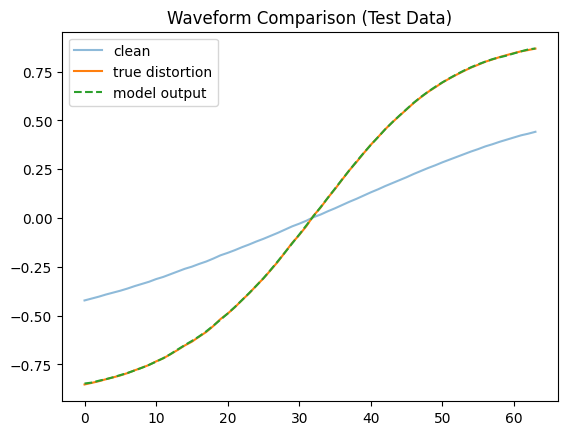

In [ ]:


SoftClipModel.eval()

with torch.no_grad():

    sample_x = X_test_SC[0:1].to(device)
    sample_y = Y_test_SC[0:1].to(device)

    pred = SoftClipModel(sample_x)

input_wave = sample_x.cpu().numpy().flatten()
target_wave = sample_y.cpu().numpy().flatten()
pred_wave = pred.cpu().numpy().flatten()

plt.plot(input_wave, label="clean", alpha=0.5)
plt.plot(target_wave, label="true distortion")
plt.plot(pred_wave, label="model output", linestyle="dashed")

plt.legend()
plt.title("Waveform Comparison (Test Data)")
plt.show()

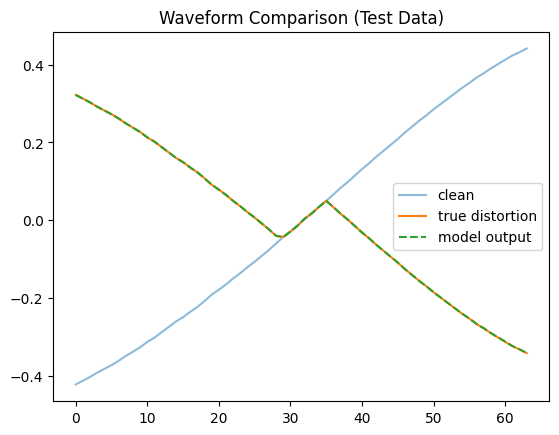

In [ ]:


HardClipModel.eval()

with torch.no_grad():

    sample_x = X_test_HC[0:1].to(device)
    sample_y = Y_test_HC[0:1].to(device)

    pred = HardClipModel(sample_x)

input_wave = sample_x.cpu().numpy().flatten()
target_wave = sample_y.cpu().numpy().flatten()
pred_wave = pred.cpu().numpy().flatten()

plt.plot(input_wave, label="clean", alpha=0.5)
plt.plot(target_wave, label="true distortion")
plt.plot(pred_wave, label="model output", linestyle="dashed")

plt.legend()
plt.title("Waveform Comparison (Test Data)")
plt.show()

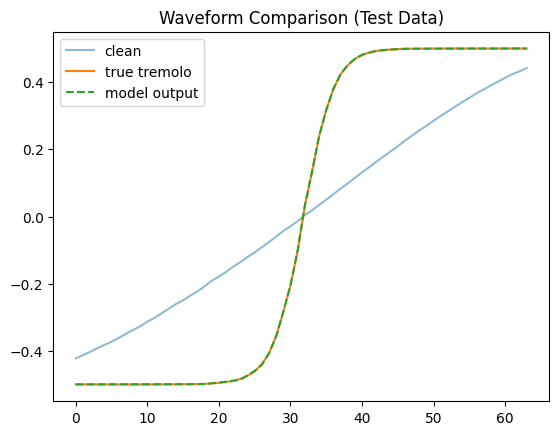

In [ ]:


TremoloModel.eval()

with torch.no_grad():

    sample_x = X_test_TM[0:1].to(device)
    sample_y = Y_test_TM[0:1].to(device)

    pred = TremoloModel(sample_x)


input_wave = sample_x[0, 0, :].cpu().numpy()
target_wave = sample_y[0, 0, :].cpu().numpy()

pred_wave = pred[0, 0, :].detach().cpu().numpy() 
plt.plot(input_wave, label="clean", alpha=0.5)
plt.plot(target_wave, label="true fuzz")
plt.plot(pred_wave, label="model output", linestyle="dashed")

plt.legend()
plt.title("Waveform Comparison (Test Data)")
plt.show()

In [ ]:
torch.save(TremoloModel.state_dict(), "Fuzz.pth")

torch.save(SoftClipModel.state_dict(), "SoftClip.pth")

torch.save(HardClipModel.state_dict(), "HardClip.pth")